# EDA

«Предсказать поведение, чтобы удержать клиентов. Вы можете проанализировать все соответствующие данные о клиентах и разработать целенаправленные программы удержания клиентов». [Наборы Данных Образца IBM]

**Объекты:**

Каждая строка представляет клиента, каждый столб содержит атрибуты клиента, описанные в столбце Metadata.

**Набор данных включает информацию о:**

- Клиенты, которые ушли в течение последнего месяца – колонка называется Churn
- Услуги, на которые подписался каждый клиент - телефон, несколько линий, интернет, онлайн-безопасность, онлайн-резервное копирование, защита устройств, техническая поддержка и потоковое телевидение и фильмы
- Информация об учетной записи клиента - как долго он был клиентом, контракт, способ оплаты, безбумажный выставление счетов, ежемесячные платежи и общие расходы
- Демографическая информация о клиентах – пол, возрастной диапазон, а также о том, есть ли у них партнеры и иждивенцы

Датасет взят из [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn?select=WA_Fn-UseC_-Telco-Customer-Churn.csv)

**Цель ноутбука:** первичное исследование данных перед feature engineering.


## Импорт библиотек

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

## Загрузка данных

In [28]:
df = pd.read_csv('../data/raw/churn.csv')
print(df.shape)
print(df.dtypes)
df.head()

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Исследуемый датасет имеет 7043 строки (объекта) с 21 признаком.  
Каждый признак имеет тип str, int64 или float64, следовательно в каждом столбце данные одного типа.  
Среди признаков найден TotalCharges имееющий тип str, хотя фактически в нем записаны числа.  

## Проверка целостности данных

In [38]:
print(f'Наличие дубликатов: {df.duplicated().any()}')
print(f'Дубликаты среди customerId: {df['customerID'].duplicated().any()}')
print(f'Наличие пропусков (NaN):\n{df.isna().sum()}')
df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.loc[df['TotalCharges_num'].isna()]

Наличие дубликатов: False
Дубликаты среди customerId: False
Наличие пропусков (NaN):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_num
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,NaN


При переводе в числовой тип признак TotalCharges появились NaN у 11 объектов, у всех 11 объектов tenure (срок прибывания) равен 0, следовательно данные клиенты еще не успели совершить транзакций, поэтому их общие траты будет разумно прировнять к 0. Помимо этого у всех стоит churn=0, что означает, что ни один из них пока не ушел, что логично, ведь данные клиенты только подключились

## Анализ целевой переменной (Churn)

Определим асболютные колличества и долю в процентах каждого класса Churn

In [ ]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

No: 5174, Yes: 1869
No: 73.46%, Yes: 26.54%


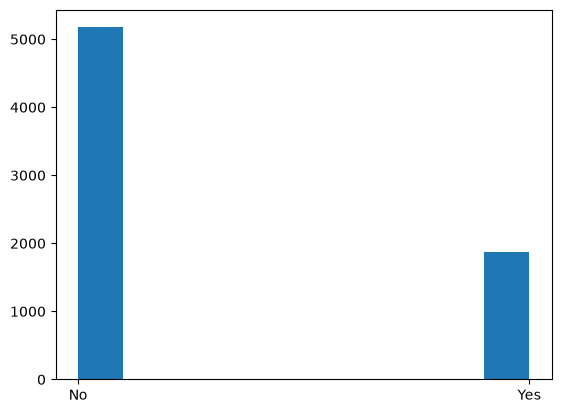

In [50]:
count_no, count_yes = df['Churn'].value_counts()
print(f'No: {count_no}, Yes: {count_yes}')

percent_no = count_no / len(df) * 100
percent_yes = 100 - percent_no
print(f'No: {percent_no:.02f}%, Yes: {percent_yes:.02f}%')

plt.hist(df['Churn'])
plt.show()

Имеем дисбаланс классов около **3/1** в сторону No. Необходимо будет стратифицировать выборку при сплите на test/train для сохранения пропорции классов.  
Accuracy в данном случае не будет информативной метрикой из-за дисбаланса классов.  
Положительный класс (Yes) - клиент ушел. Для данного датасета важнее оценивать число клиентов, которым предсказали, что они уйдут, к числу всех ушедших клиентов: ИП / (ИП + ЛО) (ИП (истинно положительный) - число клиентов которым предсказали, что они уйдут и они ушли, ЛО (ложно отрицательный) - число клиентов, которым предсказали что они останутся, но они ушли), иными словами нужен **recall** (полнота)

## Числовые признаки

### Получим описание числовых признаков:

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges_num
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


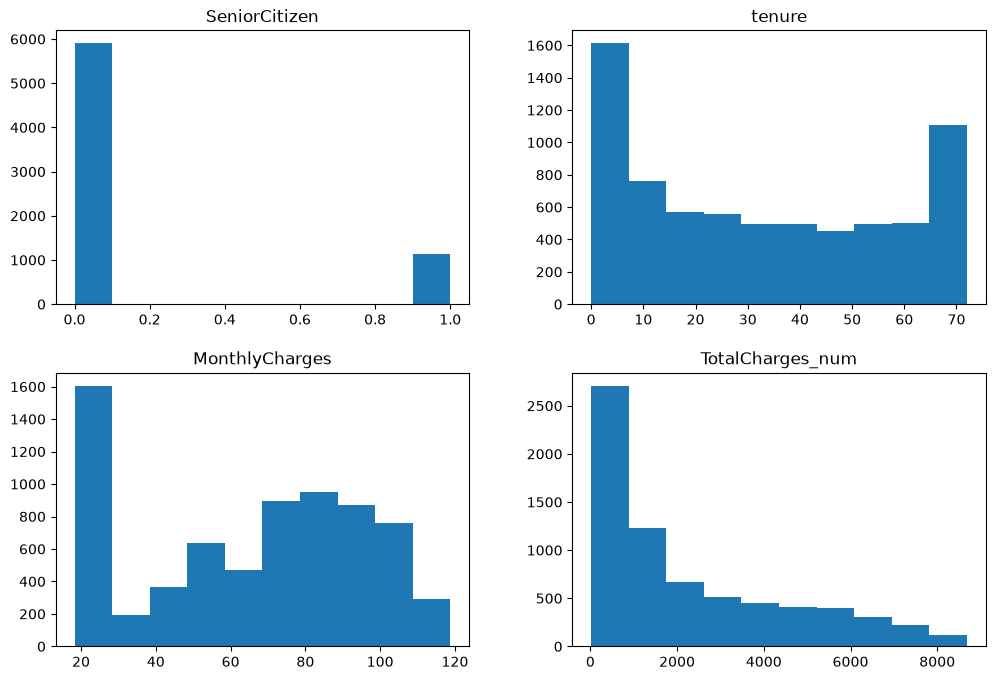

In [136]:
features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges_num']
_, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(wspace=0.25, hspace=0.25)
for ax, feature in zip(axes.ravel(), features):
    ax.set_title(feature)
    ax.hist(df[feature])
plt.show()

По таблице и графикам видим:
1. `SeniorCitizen` принимает значения 0 (не пожилой) и 1 (пожилой), виден явный перевес в сторону значений 0 (около 16% объектов имеют значение 1)
2. `tenure` имеет значения от 0 до 72 без выбросов, но с явными перевесами граничных значений относительно середины. 
3. `MonthlyCharges` (ежемесячная плата) лежит в пределах от 18.25 до 118.75 с перевесом минимальных значений.  
4. `TotalCharges_num` так же имеет максимум у минимальных значений, а также длинный хвост справа.  

`SeniorCitizen` будем считать за категориальный признак, так как он принимает значения 0 и 1

### Рассмотрим зависимости Churn от этих признаков.  
Предпологаю, что Churn будет зависеть от этих признаков следующим образом:
1. `tenure` - вероятность ухода клиента будет падать по мере роста его времени прибывания
2. `MonthlyCharges` - вероятность ухода клиентов с маленькой платой будет ниже
3. `TotalCharges_num` - вероятность ухода клиентов с большой суммой будет ниже

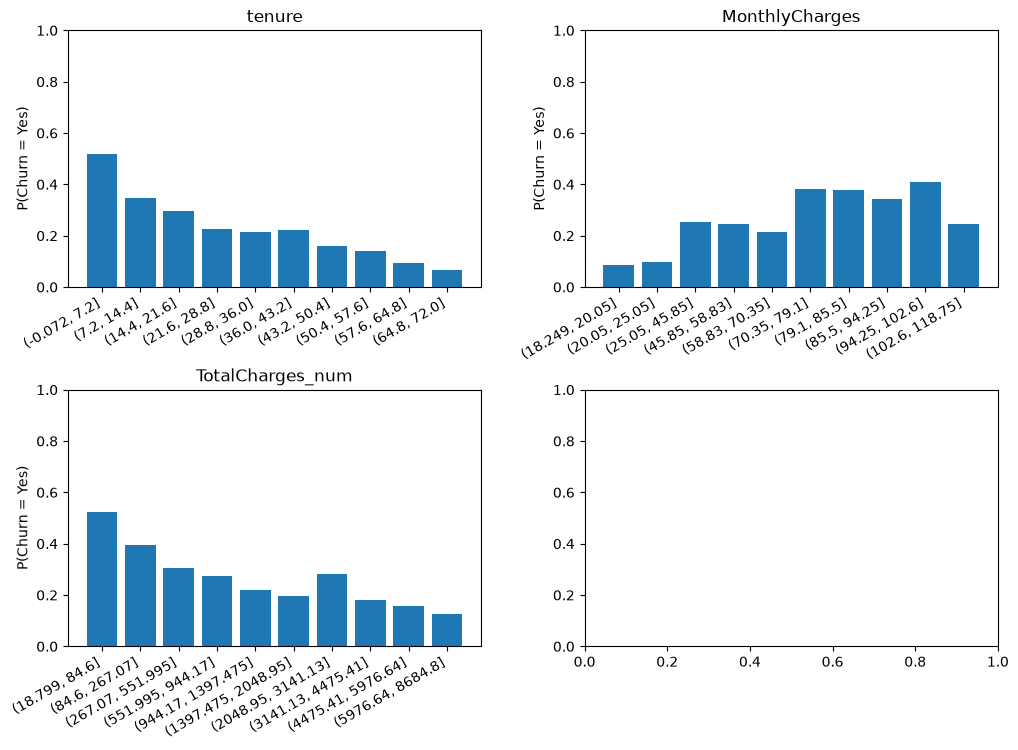

In [146]:
df['churn_num'] = (df['Churn'] == 'Yes').astype(int)

specs = {
    'tenure':            pd.cut(df['tenure'], bins=10),
    'MonthlyCharges':    pd.qcut(df['MonthlyCharges'], q=10),
    'TotalCharges_num':  pd.qcut(df['TotalCharges_num'], q=10),
}

_, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(wspace=0.25, hspace=0.4)

for ax, (feature, binning) in zip(axes.ravel(), specs.items()):
    grouped = df.groupby(binning, observed=True)['churn_num'].mean()

    ax.set_title(feature)
    ax.bar(range(len(grouped)), grouped.values)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(x) for x in grouped.index],
                       rotation=30, ha='right')
    ax.set_ylabel('P(Churn = Yes)')
    ax.set_ylim(0, 1)
plt.show()

По графикам видно:

1. вероятность ухода падает по мере увеличения числа месяцев, в течение которых клиент пользуется услугами, гипотеза подтвердилась
2. вероятность ухода растет по мере роста месячной платы, гипотеза подтвердилась
3. вероятность ухода падает по мере роста общей платы, гипотеза подтвердилась

### Корреляция числовых признаков между собой

Вероятно, высокая корреляция будет между tenure и TotalCharges_num и между MonthlyCharges и TotalCharges_num. Между tenure и MonthlyCharges, скорее всего, будет низкая корреляция.

In [145]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges_num']
df[features].corr()

,tenure,MonthlyCharges,TotalCharges_num
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges_num,0.82588,0.651065,1.000000


Видна высокая корреляция между tunure и TotalCharges_num, что можно объяснить тем, что чем дольше объект является клиентом компании, тем большую сумму за все время он заплатил, а также между MonthlyCharges и TotalCharges_num, данную корреляцию можно объяснить тем, что бОльшая месячная плата ведет к бОльшей суммарной плате за все время.  
Между tunure и MonthlyCharges наблюдается низкая корреляция признаков.

## Категориальные признаки

Будем рассматривать распеделение категорий и долю оттока клиентов для каждой категории

### Демография (gender, SeniorCitizen, Partner, Dependents)

Гипотезы:
1. `gender` - распределение по этому признаку должно быть примерно одинаковым, так же как и доля оттока для каждого пола.
2. `SeniorCitizen` - из предыдущего раздела уже знаем распределение, доля оттока среди пожилых клиентов, вероятно, будет выше, чем среди не пожилых
3. `Partner` - клиентов одиночек, возможно, будет меньше, чем клиентов с партнером, доля ухода среди клиентов с партнером, возможно, будет ниже, чем доля ухода среди клиентов без партнера
4. `Dependents` - клиентов с иждивенцами, возможно, будет больше, чем без них, доля оттока среди клиентов с Dependents = Yes будет ниже, чем среди клиентов с Dependents = No

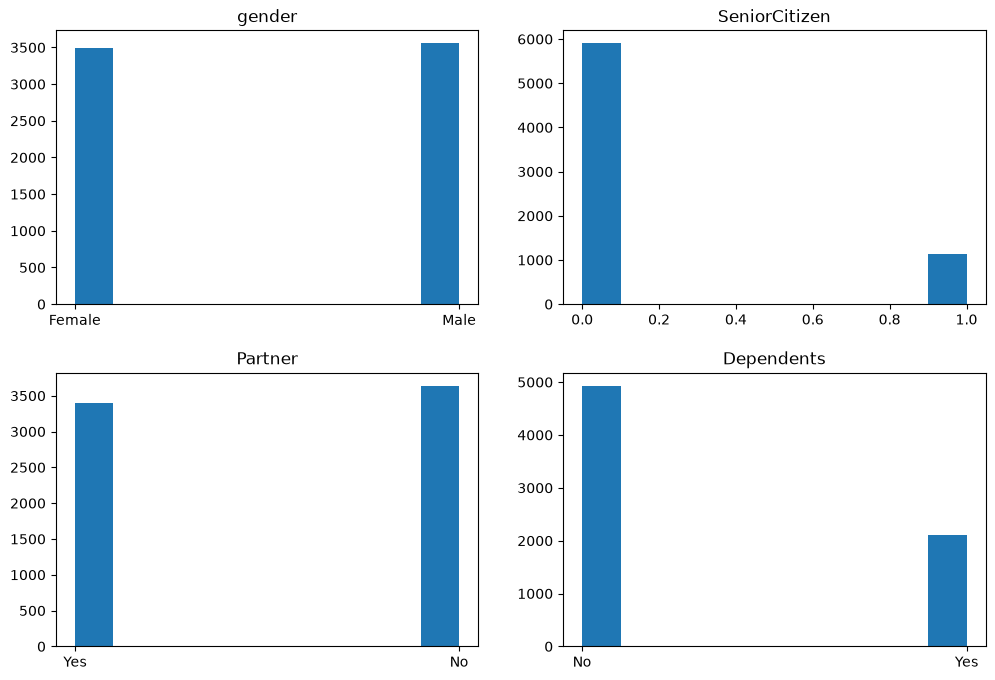

In [150]:
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

_, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.25)

for ax, feature in zip(axes.ravel(), features):
    ax.set_title(feature)
    ax.hist(df[feature])
plt.show()

По графикам распределения видно, что подтвердились гипотезы 1 и 2 (про распределения), распределение признака `Partner` оказалось примерно равномерным, а распределение `Dependents` полностью опровергло гипотезу, клиентов без иждивенцев в несколько раз больше, чем с ними.

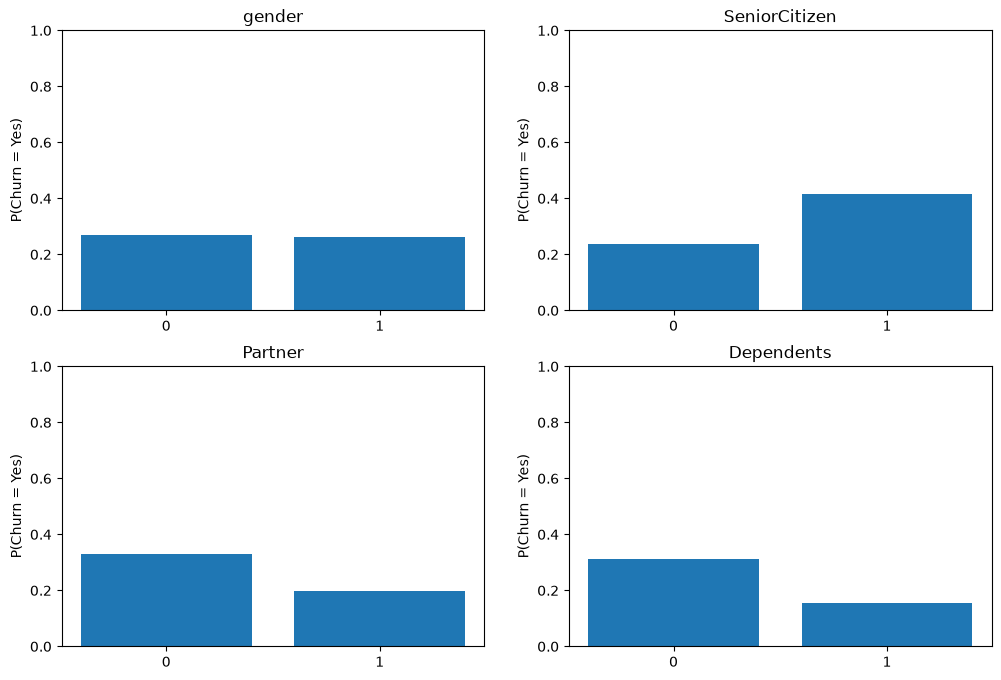

In [ ]:
_, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), features):
    grouped = df.groupby(feature)['churn_num'].mean()

    ax.set_title(feature)
    ax.bar(range(len(grouped)), grouped.values)
    ax.set_xticks(range(len(grouped)))
    ax.set_ylabel('P(Churn = Yes)')
    ax.set_ylim(0, 1)
plt.show()

По графикам вероятности оттока клиентов для каждого признака видно, что подтвердились все гипотезы (про отток).

Значимыми оказались все признаки, кроме `gender`, так как только у него равное распределение и вероятности каждой группы уйти

### Контракт и оплата (Contract, PaymentMethod, PaperlessBilling)

In [155]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [156]:
df['PaymentMethod'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [157]:
df['PaperlessBilling'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Гипотезы:
1. Клиентов со значением `Contract` = `Month-to-month` будет выше, самой малочисленной будет группа `Two year`. Доля ушедших среди `Two year` будет самой низкой, самая высока доля ушедших будет среди `Month-to-month`
2. Клиентов со значением `PaymentMethod` = `Electronic check` или `Mailed check` будет выше, чем с `automaric`. Доля ушедших среди групп `Bank transfer (automatic)` и `Credit card (automatic)` будет ниже, чем среди двух других
3. Клиентов с бумажным счетом (`PaperlessBilling = Yes`) будет меньше, чем без него. Доля оттока среди клиентов с бумажным счетом будет ниже

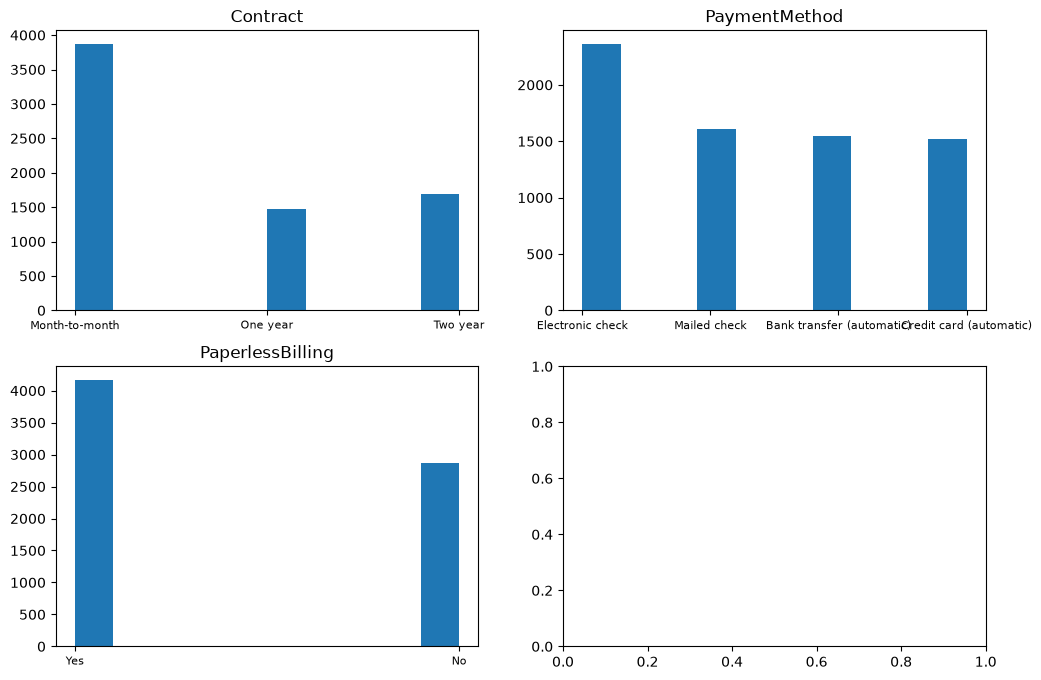

In [ ]:
features = ['Contract', 'PaymentMethod', 'PaperlessBilling']

_, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), features):
    ax.set_title(feature)
    ax.hist(df[feature])
    ax.xaxis.set_tick_params(labelsize=8)
plt.show()

Гипотезы про распределение:
1. Подтвердилась частично, число клиентов с ежемесячной оплатой действительно больше, чем остальных, однако клиентов с оплатой за 2 года чуть больше, чем клиентов с оплатой 1 год
2. Подтвердилась частично, клиентов с электронным чеком больше всех, но клиентов с чеком по почте примерно столько же, сколько и клиентов с автооплатами по кредитке или bank transfer
3. Опровергнута, клиентов с бумажными счетами больше, чет без них

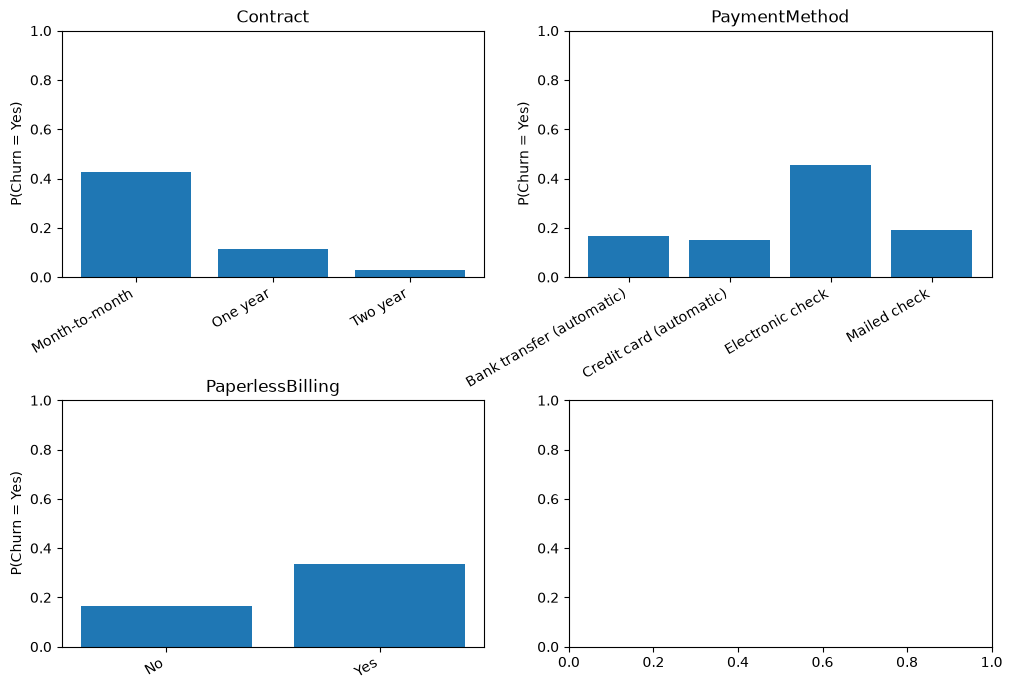

In [177]:
_, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.5)

for ax, feature in zip(axes.ravel(), features):
    grouped = df.groupby(feature)['churn_num'].mean()

    ax.set_title(feature)
    ax.bar(grouped.keys(), grouped.values)
    ax.set_xticks(grouped.keys())
    ax.set_xticklabels([str(x) for x in grouped.index],
                    rotation=30, ha='right')
    ax.set_ylabel('P(Churn = Yes)')
    ax.set_ylim(0, 1)
plt.show()

Гипотезы про вероятность оттока клиентов:
1. Подтвердилась, клиенты с ежемесячной оплатой имеют кратно большую вероятность уйти
2. Подтвердилась, клиенты с автоматической оплатов имеют меньшую вероятность уйти
3. Опровергнута, наоборот, клиенты с бумажным чеком имеют более высокий шанс оттока

Важными оказались все признаки, так как в каждом признаке каждая группа имеет разные шансы на отток клиентов, разве что в признаке `PaymentMethod` не важен способ оплаты, если это не `Electronic chek`, так как остальные группы имеют примерно одинаковые шансы на отток

### Услуги (PhoneService, MultipleLines, InternetService и весь блок доп.услуг)

In [191]:
def show_groupes(feature):
    print(f'{feature}:\n{df[feature].unique()}\n')

features = [
    'PhoneService', 
    'MultipleLines', 
    'InternetService', 
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
for feature in features:
    show_groupes(feature)

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str



Из значений категорий в признаках видно, что многие признаки зависят от InternetService, поэтому, скорее всего, значение в этом признаке будет важным, как для распределения, так и для оттока клиентов

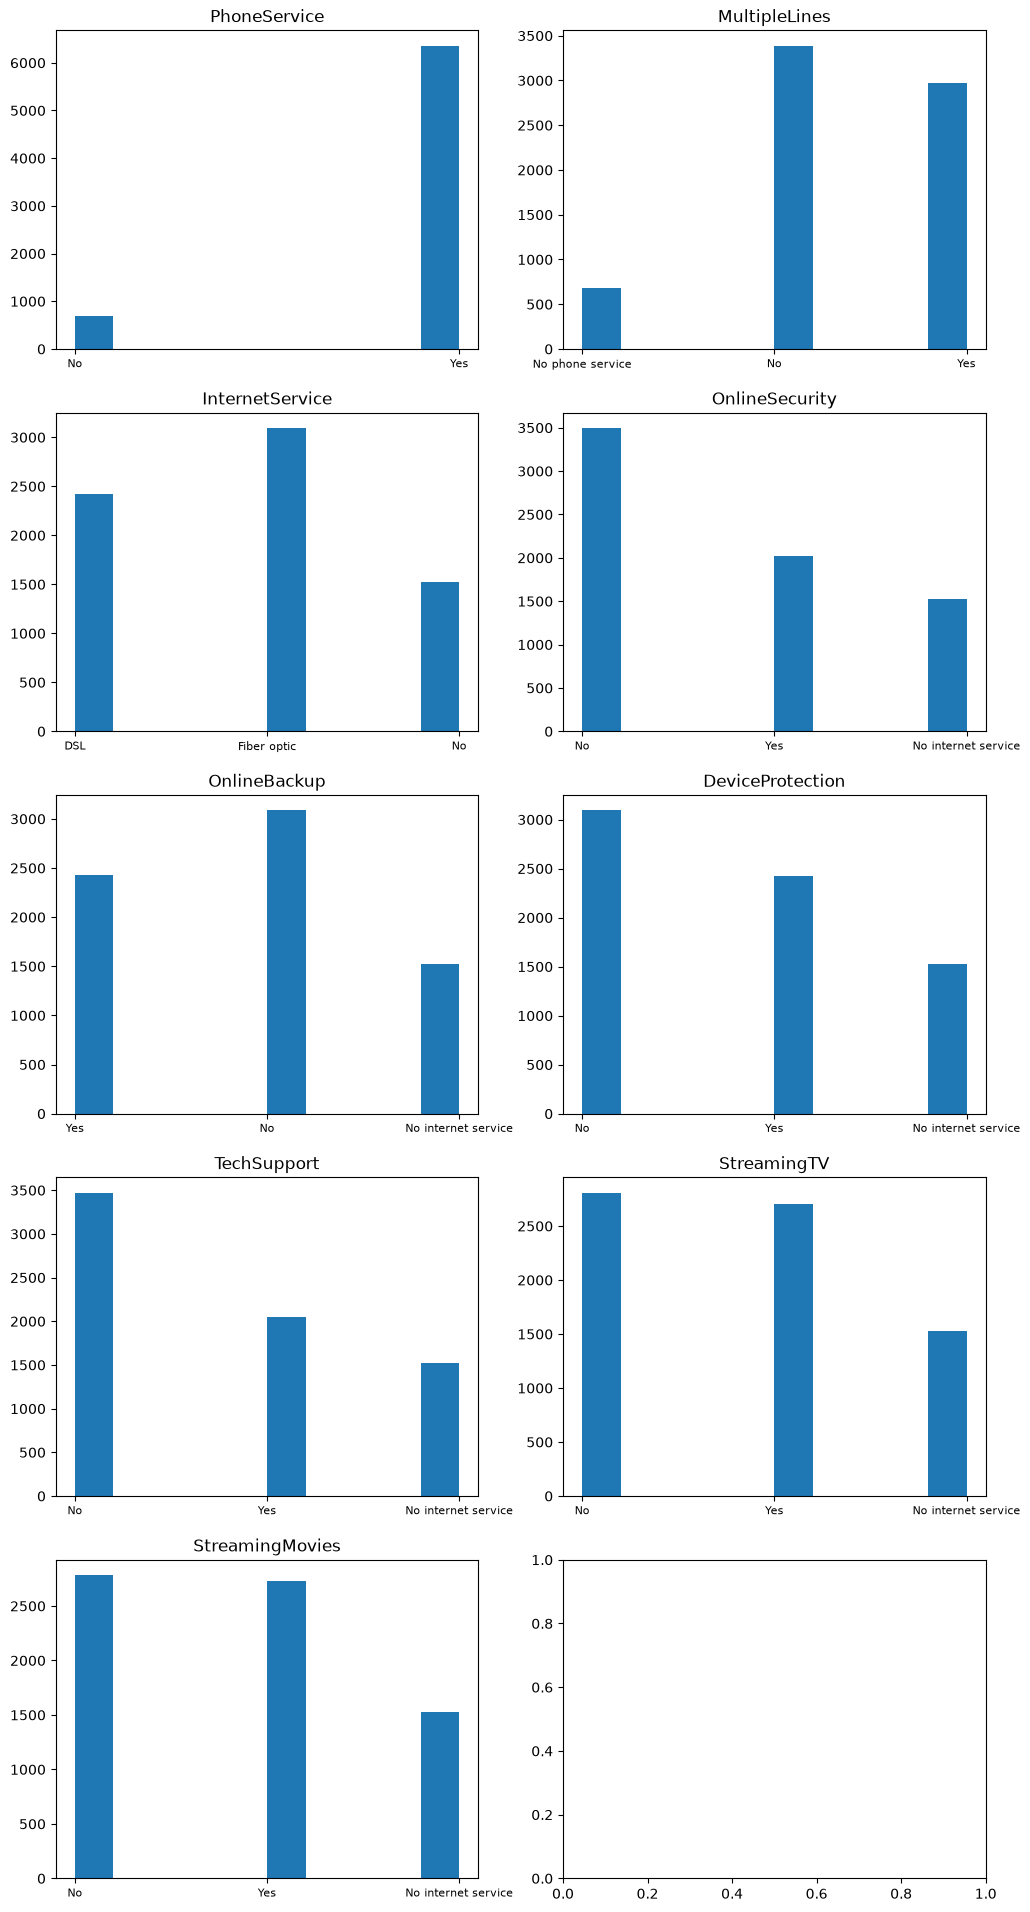

In [192]:
_, axes = plt.subplots(5, 2, figsize=(12, 24))

for ax, feature in zip(axes.ravel(), features):
    ax.set_title(feature)
    ax.hist(df[feature])
    ax.xaxis.set_tick_params(labelsize=8)
plt.show()

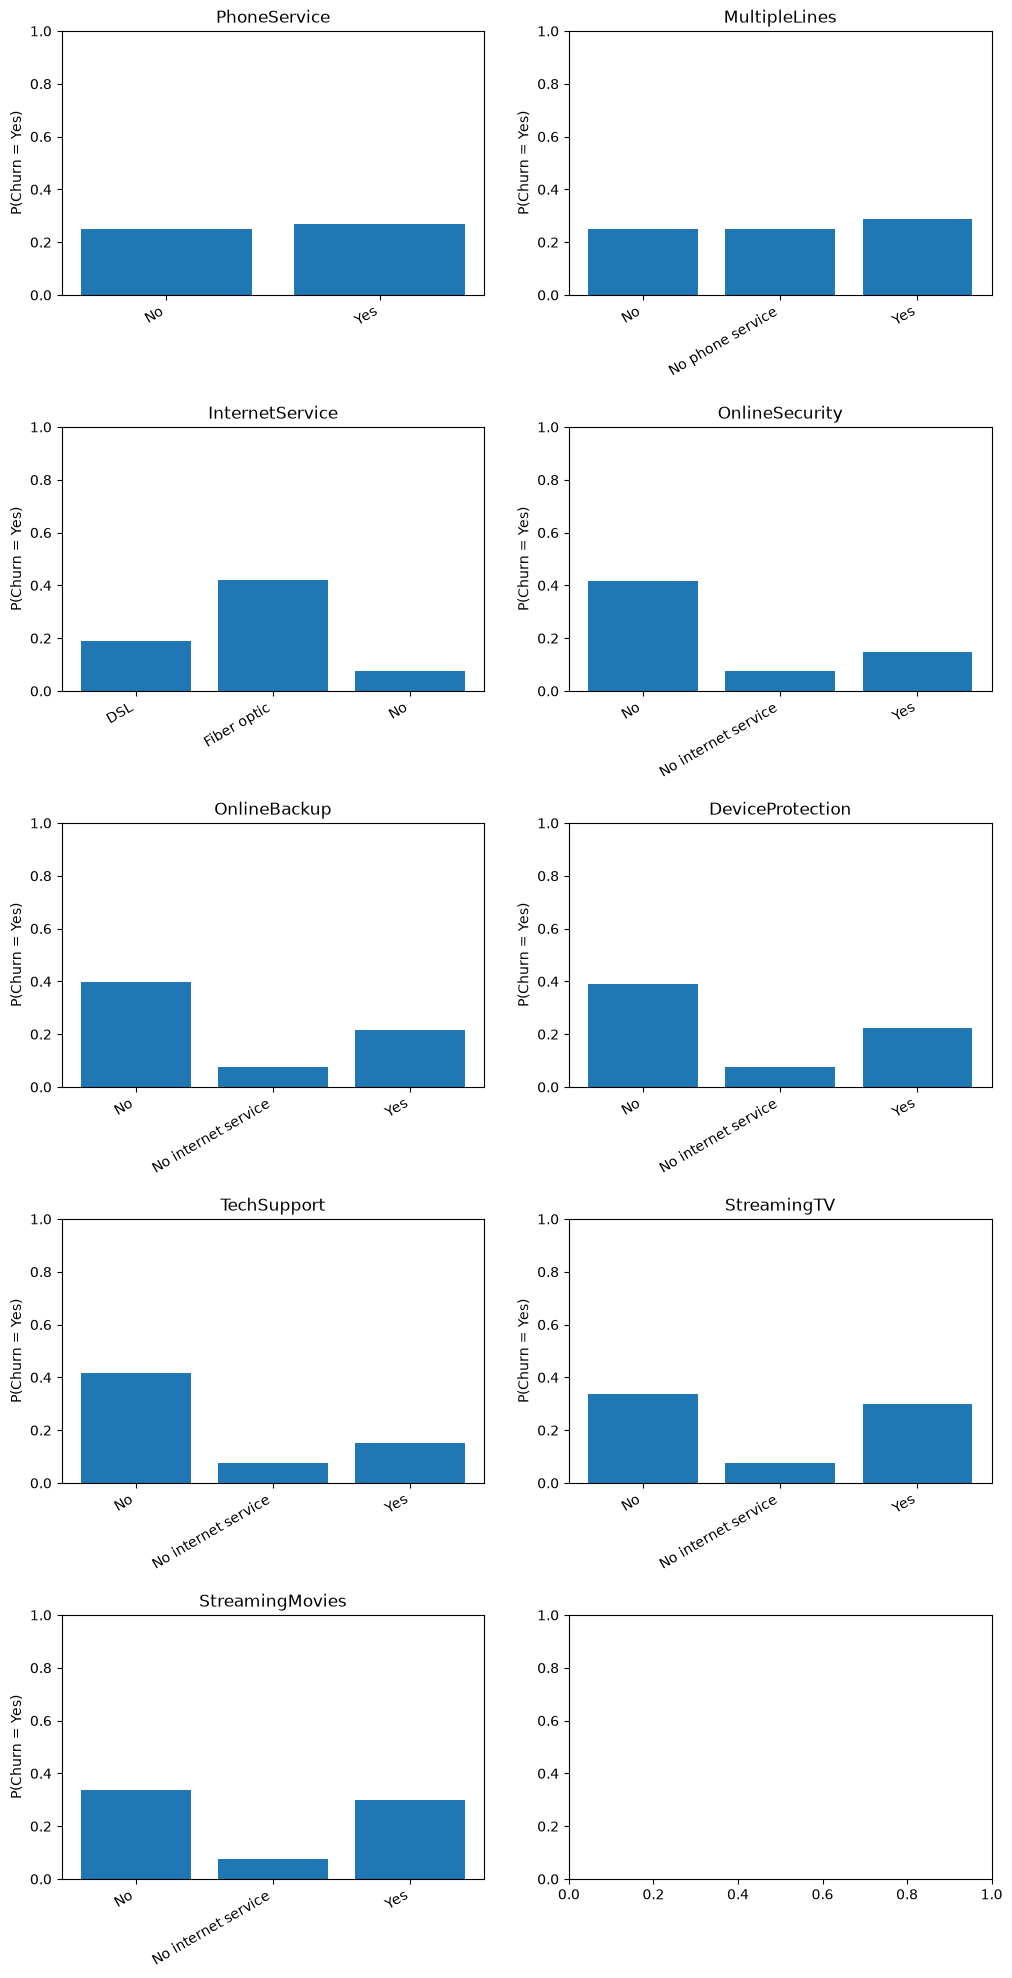

In [194]:
_, axes = plt.subplots(5, 2, figsize=(12, 24))
plt.subplots_adjust(hspace=0.5)

for ax, feature in zip(axes.ravel(), features):
    grouped = df.groupby(feature)['churn_num'].mean()

    ax.set_title(feature)
    ax.bar(grouped.keys(), grouped.values)
    ax.set_xticks(grouped.keys())
    ax.set_xticklabels([str(x) for x in grouped.index],
                    rotation=30, ha='right')
    ax.set_ylabel('P(Churn = Yes)')
    ax.set_ylim(0, 1)
plt.show()

По графикам видно:
1. Несмотря на сильный дисбаланс классов у `PhoneService`, данный признак почти не влияет на отток клиентов (вероятность оттока клиента у групп примерно равны)
2. Для `MultipleLines` такая же ситуация
3. Остальные признаки важны для прогнозирования оттока

### Общий вывод по секции

Признаки, от которых особо не зависит вероятсноть оттока клиентов:
1. `PhoneService`
2. `MultipleLines`
3. `gender`

Возможно, признак `PaymentMethod` стоит переделать в бинарный (`Electronic chek` = 0/1), так как остальные группы данного признака имеют одинаковые шансы на отток
